In [1]:
# Import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings

import torch
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import kagglehub

c:\Users\Gaben\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\utils\generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


## 1. Load and Explore the Dataset

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [6]:
# Download Kaggle dataset
print("Downloading Kaggle dataset: jp797498e/twitter-entity-sentiment-analysis")

# Download using kagglehub (requires kaggle.json credentials)
path = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")
print(f"Dataset downloaded to: {path}")

# List files in the dataset
files = os.listdir(path)
print(f"\nFiles in dataset: {files}")

# Load the data - look for CSV files
csv_files = [f for f in files if f.endswith('.csv')]
print(f"CSV files found: {csv_files}")

# Load the main dataset
df = pd.read_csv(os.path.join(path, csv_files[0]))
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

Dataset downloaded to: C:\Users\Gaben\.cache\kagglehub\datasets\jp797498e\twitter-entity-sentiment-analysis\versions\2

Files in dataset: ['twitter_training.csv', 'twitter_validation.csv']
CSV files found: ['twitter_training.csv', 'twitter_validation.csv']

Dataset shape: (74681, 4)
Columns: ['2401', 'Borderlands', 'Positive', 'im getting on borderlands and i will murder you all ,']

First few rows:
   2401  Borderlands  Positive  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

  im getting on borderlands and i will murder you all ,  
0  I am coming to the borders and I will kill you...     
1  im getting on borderlands and i will kill you ...     
2  im coming on borderlands and i will murder you...     
3  im getting on borderlands 2 and i will murder ...     
4  im getting into borderlands and i can murder y...     


In [8]:
# Inspect dataset structure
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)

print("\nColumn names:")
for i, col in enumerate(df.columns):
    print(f"  {i}: {col}")
    print(f"      Sample values: {df[col].head(3).tolist()}")

print("\n" + "="*50)
print("\nDataset shape:", df.shape)
print("Data types:\n", df.dtypes)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None


Column names:
  0: 2401
      Sample values: [2401, 2401, 2401]
  1: Borderlands
      Sample values: ['Borderlands', 'Borderlands', 'Borderlands']
  2: Positive
      Sample values: ['Positive', 'Positive', 'Positive']
  3: im getting on borderlands and i will murder you all ,
      Sample values: ['I am coming to the bo

Identified columns:
  ID: 2401
  Entity: Borderlands
  Sentiment: Positive
  Text: im getting on borderlands and i will murder you all ,

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None


Missing Values:
2401                                                       0
Borderlands                                                0
Positive                                       

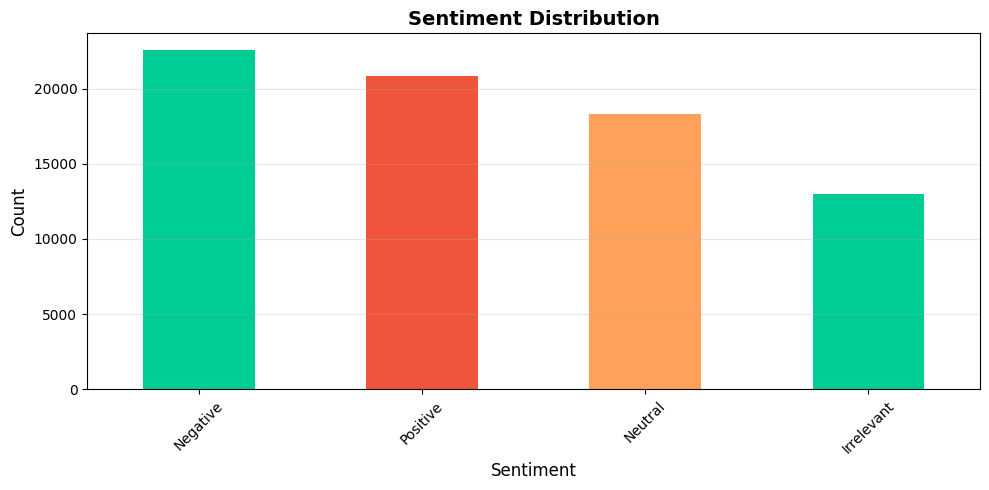



Sample texts:

Positive:
  1. I am coming to the borders and I will kill you all,...
  2. im getting on borderlands and i will kill you all,...

Neutral:
  1. Rock-Hard La Varlope, RARE & POWERFUL, HANDSOME JACKPOT, Borderlands 3 (Xbox) dlvr.it/RMTrgF  ...
  2. Rock-Hard La Varlope, RARE & POWERFUL, HANDSOME JACKPOT, Borderlands 3 (Xbox) dlvr.it / RMTrgF...

Negative:
  1. the biggest dissappoinment in my life came out a year ago fuck borderlands 3...
  2. The biggest disappointment of my life came a year ago....

Irrelevant:
  1. Appreciate the (sonic) concepts / praxis Valenzuela and Landa-Posas thread together in this talk: mu...
  2. Appreciate the (sound) concepts / practices that Valenzuela and Landa-Posas combine in this lecture:...


In [10]:
# Exploratory Data Analysis (EDA)

# Define column names based on actual structure
sentiment_col = 'Positive'  # Column 2
text_col = df.columns[3]     # Column 3 (the tweet text)
entity_col = 'Borderlands'   # Column 1  
id_col = df.columns[0]       # Column 0

print(f"Identified columns:")
print(f"  ID: {id_col}")
print(f"  Entity: {entity_col}")
print(f"  Sentiment: {sentiment_col}")
print(f"  Text: {text_col}")

print("\n" + "="*50)
print("Dataset Info:")
print(df.info())

print("\n" + "="*50)
print("\nMissing Values:")
print(df.isnull().sum())

print("\n" + "="*50)
print(f"\nUnique sentiment labels:")
print(df[sentiment_col].unique())
print(f"\nSentiment distribution:")
print(df[sentiment_col].value_counts())

# Visualize sentiment distribution
plt.figure(figsize=(10, 5))
df[sentiment_col].value_counts().plot(kind='bar', color=['#00CC96', '#EF553B', '#FFA15A'])
plt.title('Sentiment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n" + "="*50)
print(f"\nSample texts:")
for sentiment in df[sentiment_col].unique():
    print(f"\n{sentiment}:")
    samples = df[df[sentiment_col] == sentiment][text_col].head(2).values
    for i, text in enumerate(samples, 1):
        print(f"  {i}. {str(text)[:100]}...")


Text Statistics:
Average text length: 107.81 characters
Max text length: 957 characters
Min text length: 1 characters
Average word count: 19.06 words
Max word count: 198 words


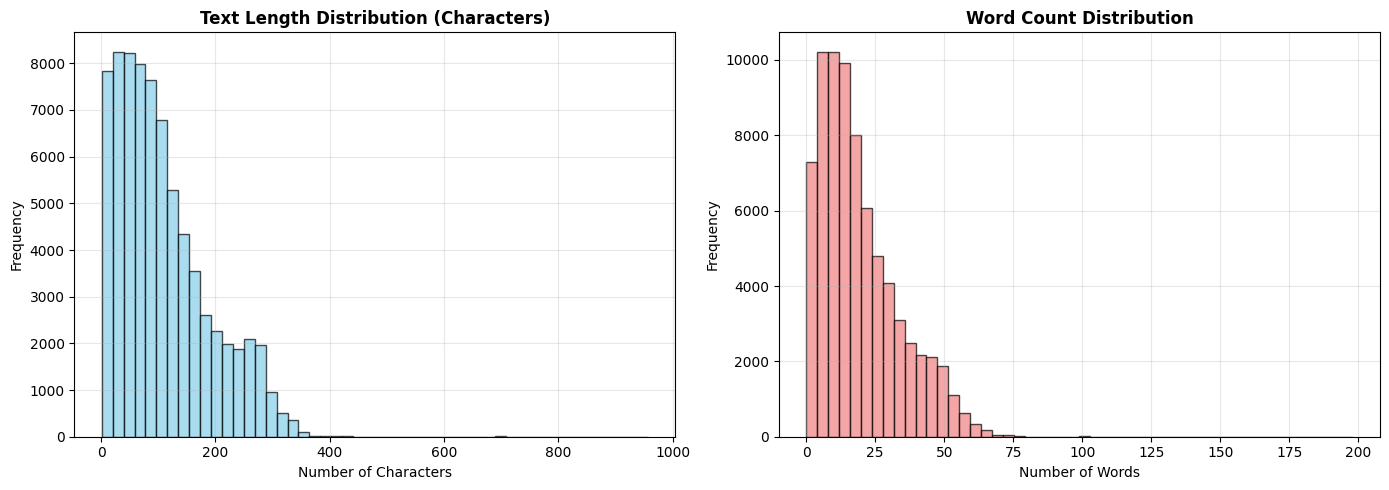

In [11]:
# Text statistics
df['text_length'] = df[text_col].astype(str).apply(len)
df['word_count'] = df[text_col].astype(str).apply(lambda x: len(x.split()))

print(f"\nText Statistics:")
print(f"Average text length: {df['text_length'].mean():.2f} characters")
print(f"Max text length: {df['text_length'].max()} characters")
print(f"Min text length: {df['text_length'].min()} characters")
print(f"Average word count: {df['word_count'].mean():.2f} words")
print(f"Max word count: {df['word_count'].max()} words")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['text_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Text Length Distribution (Characters)', fontweight='bold')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

axes[1].hist(df['word_count'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_title('Word Count Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Data Preprocessing and Tokenization

In [12]:
# Data preprocessing

# Remove rows with missing text or sentiment
initial_size = len(df)
df = df.dropna(subset=[text_col, sentiment_col])
df = df[df[text_col].astype(str).str.strip() != '']
print(f"Removed {initial_size - len(df)} rows with missing values")
print(f"Final dataset size: {len(df)}")

# Create label mapping
unique_sentiments = sorted([s for s in df[sentiment_col].unique() if pd.notna(s)])
label_to_id = {label: idx for idx, label in enumerate(unique_sentiments)}
id_to_label = {idx: label for label, idx in label_to_id.items()}

print(f"\nLabel mapping:")
for label, idx in label_to_id.items():
    print(f"  {label} → {idx}")

# Add label IDs to dataframe
df['label'] = df[sentiment_col].map(label_to_id)

# Clean text function
import re

def clean_text(text):
    """Clean text data"""
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    # Remove HTML entities
    text = re.sub(r'&[a-z]+;', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("\nCleaning text data...")
df['cleaned_text'] = df[text_col].apply(clean_text)

print("\n✓ Data preprocessing completed!")

Removed 858 rows with missing values
Final dataset size: 73823

Label mapping:
  Irrelevant → 0
  Negative → 1
  Neutral → 2
  Positive → 3

Cleaning text data...

✓ Data preprocessing completed!


In [13]:
# Load DistilBERT tokenizer
print("Loading DistilBERT tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
print("✓ Tokenizer loaded successfully!")

# Tokenization settings
MAX_LENGTH = 128

# Tokenize texts
print(f"\nTokenizing texts (MAX_LENGTH={MAX_LENGTH})...")

def tokenize_function(text):
    """Tokenize text"""
    return tokenizer(
        text,
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors=None
    )

tokenized_data = []
for idx, text in enumerate(tqdm(df['cleaned_text'], desc="Tokenizing")):
    encoded = tokenize_function(text)
    tokenized_data.append({
        'input_ids': encoded['input_ids'],
        'attention_mask': encoded['attention_mask'],
        'label': df['label'].iloc[idx]
    })

print(f"✓ Tokenization completed! Total samples: {len(tokenized_data)}")

# Show token count statistics
token_counts = [len(item['input_ids']) for item in tokenized_data]
print(f"\nToken count statistics:")
print(f"  Average: {np.mean(token_counts):.2f}")
print(f"  Max: {np.max(token_counts)}")
print(f"  Min: {np.min(token_counts)}")

# Sample tokenization
print(f"\nSample tokenization:")
sample_idx = 0
print(f"Text: {df['cleaned_text'].iloc[sample_idx][:80]}...")
print(f"Token IDs: {tokenized_data[sample_idx]['input_ids'][:20]}...")
print(f"Attention mask: {tokenized_data[sample_idx]['attention_mask'][:20]}...")
print(f"Label: {tokenized_data[sample_idx]['label']} ({id_to_label[tokenized_data[sample_idx]['label']]})")

Loading DistilBERT tokenizer...


c:\Users\Gaben\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

✓ Tokenizer loaded successfully!

Tokenizing texts (MAX_LENGTH=128)...


Tokenizing: 100%|██████████| 73823/73823 [00:19<00:00, 3860.24it/s]

✓ Tokenization completed! Total samples: 73823

Token count statistics:
  Average: 128.00
  Max: 128
  Min: 128

Sample tokenization:
Text: i am coming to the borders and i will kill you all,...
Token IDs: [101, 1045, 2572, 2746, 2000, 1996, 6645, 1998, 1045, 2097, 3102, 2017, 2035, 1010, 102, 0, 0, 0, 0, 0]...
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]...
Label: 3 (Positive)


## 4. Prepare Training and Validation Splits

In [14]:
# Create train/val/test splits
print("Creating train/validation/test splits...")

# First split: 80% train, 20% temp (val+test)
train_data, temp_data, train_labels, temp_labels = train_test_split(
    tokenized_data,
    df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label'].values
)

# Second split: 50% validation, 50% test from temp data
val_data, test_data, val_labels, test_labels = train_test_split(
    temp_data,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f"\nSplit sizes:")
print(f"  Training:   {len(train_data)} samples ({len(train_data)/len(tokenized_data)*100:.1f}%)")
print(f"  Validation: {len(val_data)} samples ({len(val_data)/len(tokenized_data)*100:.1f}%)")
print(f"  Test:       {len(test_data)} samples ({len(test_data)/len(tokenized_data)*100:.1f}%)")

# Verify label distribution
train_label_dist = pd.Series(train_labels).value_counts().sort_index()
val_label_dist = pd.Series(val_labels).value_counts().sort_index()
test_label_dist = pd.Series(test_labels).value_counts().sort_index()

print(f"\nLabel distribution:")
print(f"\nTraining set:")
for label_id, count in train_label_dist.items():
    print(f"  {id_to_label[label_id]}: {count} ({count/len(train_labels)*100:.1f}%)")

print(f"\nValidation set:")
for label_id, count in val_label_dist.items():
    print(f"  {id_to_label[label_id]}: {count} ({count/len(val_labels)*100:.1f}%)")

print(f"\nTest set:")
for label_id, count in test_label_dist.items():
    print(f"  {id_to_label[label_id]}: {count} ({count/len(test_labels)*100:.1f}%)")

print(f"\n✓ Data split completed!")

Creating train/validation/test splits...

Split sizes:
  Training:   59058 samples (80.0%)
  Validation: 7382 samples (10.0%)
  Test:       7383 samples (10.0%)

Label distribution:

Training set:
  Irrelevant: 10274 (17.4%)
  Negative: 17849 (30.2%)
  Neutral: 14441 (24.5%)
  Positive: 16494 (27.9%)

Validation set:
  Irrelevant: 1284 (17.4%)
  Negative: 2231 (30.2%)
  Neutral: 1805 (24.5%)
  Positive: 2062 (27.9%)

Test set:
  Irrelevant: 1284 (17.4%)
  Negative: 2232 (30.2%)
  Neutral: 1805 (24.4%)
  Positive: 2062 (27.9%)

✓ Data split completed!


In [15]:
# Load DistilBERT model
print(f"Loading DistilBERT model for {len(label_to_id)} classes...")
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(label_to_id),
    id2label=id_to_label,
    label2id=label_to_id
)

# Move model to device
model.to(device)

# Print model info
print(f"✓ Model loaded successfully!")
print(f"\nModel architecture:")
print(f"  Model type: DistilBERT")
print(f"  Number of labels: {len(label_to_id)}")
print(f"  Labels: {list(id_to_label.values())}")
print(f"  Device: {device}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel parameters:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")
print(f"  Non-trainable: {total_params - trainable_params:,}")

Loading DistilBERT model for 4 classes...


c:\Users\Gaben\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'pre_classifier.weight', 'classifier.weight', 'pre_classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded successfully!

Model architecture:
  Model type: DistilBERT
  Number of labels: 4
  Labels: ['Irrelevant', 'Negative', 'Neutral', 'Positive']
  Device: cuda

Model parameters:
  Total: 66,956,548
  Trainable: 66,956,548
  Non-trainable: 0


## 5. Create PyTorch DataLoaders

In [16]:
# Create PyTorch Dataset class
class SentimentDataset(Dataset):
    """Custom PyTorch Dataset for sentiment analysis"""
    
    def __init__(self, data):
        self.data = data
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        return {
            'input_ids': torch.tensor(item['input_ids'], dtype=torch.long),
            'attention_mask': torch.tensor(item['attention_mask'], dtype=torch.long),
            'labels': torch.tensor(item['label'], dtype=torch.long)
        }

# Create datasets
train_dataset = SentimentDataset(train_data)
val_dataset = SentimentDataset(val_data)
test_dataset = SentimentDataset(test_data)

print("Creating DataLoaders...")

# Hyperparameters
BATCH_SIZE = 16

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"✓ DataLoaders created successfully!")
print(f"\nDataLoader info:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Test a batch
print(f"\nSample batch from training data:")
sample_batch = next(iter(train_loader))
print(f"  input_ids shape: {sample_batch['input_ids'].shape}")
print(f"  attention_mask shape: {sample_batch['attention_mask'].shape}")
print(f"  labels shape: {sample_batch['labels'].shape}")
print(f"  Labels in batch: {sample_batch['labels'].tolist()}")

Creating DataLoaders...
✓ DataLoaders created successfully!

DataLoader info:
  Batch size: 16
  Training batches: 3692
  Validation batches: 462
  Test batches: 462

Sample batch from training data:
  input_ids shape: torch.Size([16, 128])
  attention_mask shape: torch.Size([16, 128])
  labels shape: torch.Size([16])
  Labels in batch: [2, 3, 0, 3, 2, 0, 1, 3, 2, 2, 2, 1, 1, 3, 3, 2]


## 6. Configure Training Parameters

In [19]:
# Training hyperparameters
EPOCHS = 3
LEARNING_RATE = 2e-5
WARMUP_STEPS = 500
WEIGHT_DECAY = 0.01

print("Training Configuration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Warmup Steps: {WARMUP_STEPS}")
print(f"  Weight Decay: {WEIGHT_DECAY}")
print(f"  Device: {device}")

# Calculate total training steps
total_steps = len(train_loader) * EPOCHS

# Setup optimizer
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Setup learning rate scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

print(f"\nOptimizer: AdamW")
print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {WARMUP_STEPS}")
print(f"\n✓ Training configuration completed!")

Training Configuration:
  Epochs: 3
  Learning Rate: 2e-05
  Batch Size: 16
  Warmup Steps: 500
  Weight Decay: 0.01
  Device: cuda

Optimizer: AdamW
Total training steps: 11076
Warmup steps: 500

✓ Training configuration completed!


## 7. Fine-tune the Model

In [20]:
# Training loop
print("Starting fine-tuning...\n")

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(EPOCHS):
    print(f"\n{'='*60}")
    print(f"EPOCH {epoch + 1}/{EPOCHS}")
    print(f"{'='*60}")
    
    # Training phase
    model.train()
    total_train_loss = 0
    
    progress_bar = tqdm(train_loader, desc="Training")
    for batch in progress_bar:
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        total_train_loss += loss.item()
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        progress_bar.set_postfix({'loss': loss.item()})
    
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    print(f"\nTraining Loss: {avg_train_loss:.4f}")
    
    # Validation phase
    model.eval()
    total_val_loss = 0
    val_predictions = []
    val_true_labels = []
    
    with torch.no_grad():
        progress_bar = tqdm(val_loader, desc="Validating")
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            total_val_loss += loss.item()
            
            # Get predictions
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=1)
            
            val_predictions.extend(predictions.cpu().numpy())
            val_true_labels.extend(labels.cpu().numpy())
            
            progress_bar.set_postfix({'loss': loss.item()})
    
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # Calculate validation accuracy
    val_accuracy = accuracy_score(val_true_labels, val_predictions)
    val_accuracies.append(val_accuracy)
    
    print(f"Validation Loss: {avg_val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

print(f"\n{'='*60}")
print("Fine-tuning completed!")
print(f"{'='*60}")

Starting fine-tuning...


EPOCH 1/3


Training: 100%|██████████| 3692/3692 [04:16<00:00, 14.38it/s, loss=0.0958]



Training Loss: 0.7696


Validating: 100%|██████████| 462/462 [00:10<00:00, 45.68it/s, loss=0.279] 


Validation Loss: 0.5518
Validation Accuracy: 0.8041 (80.41%)

EPOCH 2/3


...

Validation Loss: 0.3716
Validation Accuracy: 0.8775 (87.75%)

EPOCH 3/3


Training: 100%|██████████| 3692/3692 [04:11<00:00, 14.66it/s, loss=0.000568]



Training Loss: 0.1792


Validating: 100%|██████████| 462/462 [00:09<00:00, 46.58it/s, loss=0.738]  

Validation Loss: 0.3622
Validation Accuracy: 0.9003 (90.03%)

Fine-tuning completed!


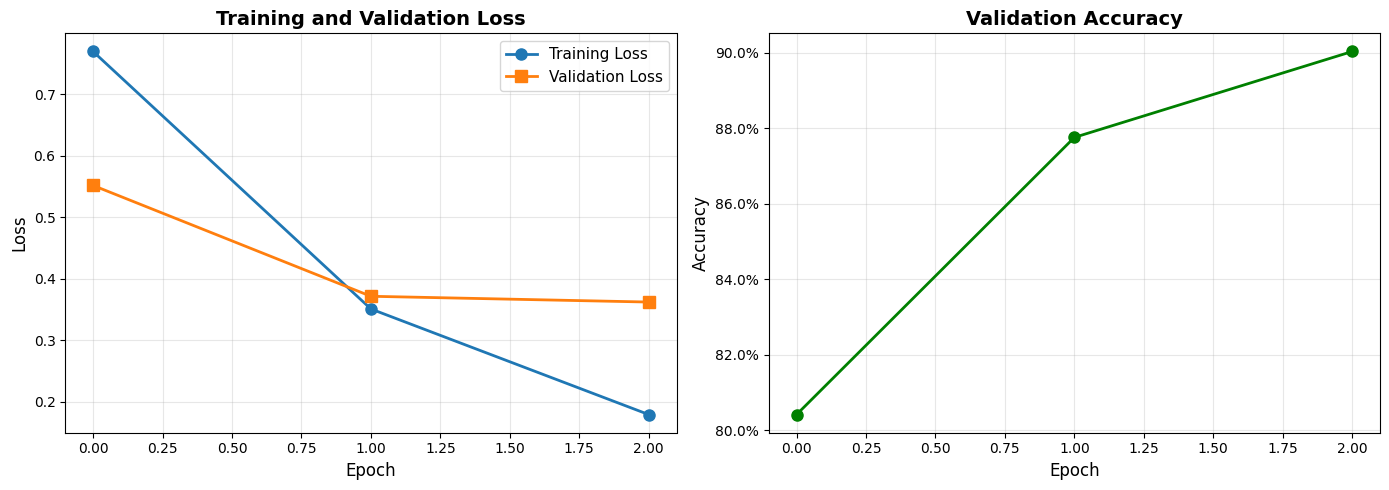

Final Validation Accuracy: 0.9003 (90.03%)


In [21]:
# Visualize training progress
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(train_losses, 'o-', label='Training Loss', linewidth=2, markersize=8)
axes[0].plot(val_losses, 's-', label='Validation Loss', linewidth=2, markersize=8)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy plot
axes[1].plot(val_accuracies, 'o-', color='green', linewidth=2, markersize=8)
axes[1].set_title('Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f} ({val_accuracies[-1]*100:.2f}%)")

## 8. Evaluate Model Performance

In [22]:
# Evaluate on test set
print("Evaluating model on test set...\n")

model.eval()
test_predictions = []
test_true_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids =batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)
        
        test_predictions.extend(predictions.cpu().numpy())
        test_true_labels.extend(labels.cpu().numpy())

# Calculate metrics
test_accuracy = accuracy_score(test_true_labels, test_predictions)
test_precision = precision_score(test_true_labels, test_predictions, average='weighted', zero_division=0)
test_recall = recall_score(test_true_labels, test_predictions, average='weighted', zero_division=0)
test_f1 = f1_score(test_true_labels, test_predictions, average='weighted', zero_division=0)

print(f"\n{'='*60}")
print("TEST SET METRICS")
print(f"{'='*60}")
print(f"Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")

# Classification report
print(f"\n{'='*60}")
print("CLASSIFICATION REPORT")
print(f"{'='*60}\n")
print(classification_report(test_true_labels, test_predictions, target_names=list(id_to_label.values())))

# Confusion matrix
cm = confusion_matrix(test_true_labels, test_predictions)
print(f"\nConfusion Matrix:")
print(cm)

Evaluating model on test set...



Testing: 100%|██████████| 462/462 [00:09<00:00, 47.71it/s]


TEST SET METRICS
Accuracy:  0.8956 (89.56%)
Precision: 0.8957
Recall:    0.8956
F1-Score:  0.8956

CLASSIFICATION REPORT

              precision    recall  f1-score   support

  Irrelevant       0.89      0.87      0.88      1284
    Negative       0.92      0.91      0.91      2232
     Neutral       0.89      0.89      0.89      1805
    Positive       0.88      0.90      0.89      2062

    accuracy                           0.90      7383
   macro avg       0.89      0.89      0.89      7383
weighted avg       0.90      0.90      0.90      7383


Confusion Matrix:
[[1122   46   46   70]
 [  33 2026   85   88]
 [  52   60 1607   86]
 [  53   77   75 1857]]


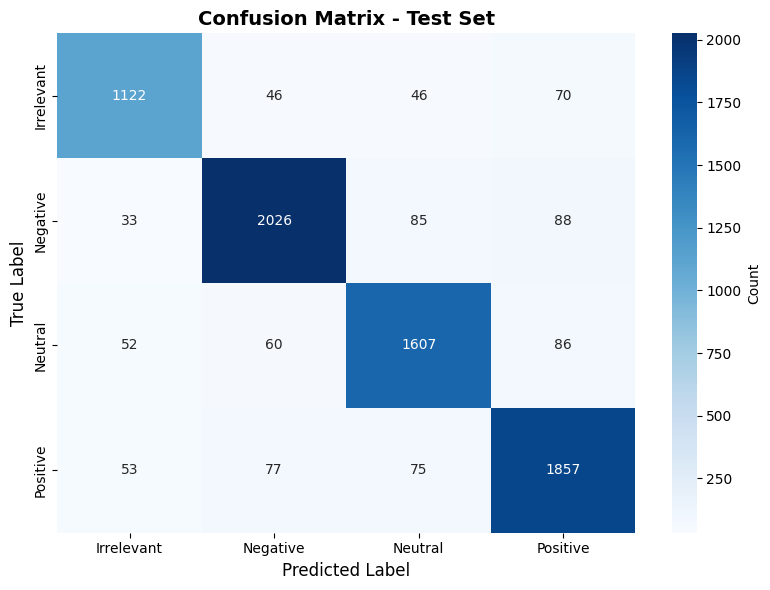

In [23]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(id_to_label.values()),
    yticklabels=list(id_to_label.values()),
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

In [24]:
# Save model locally
LOCAL_MODEL_PATH = "./fine_tuned_distilbert_sentiment"

print(f"Saving model to: {LOCAL_MODEL_PATH}\n")

# Create directory if it doesn't exist
os.makedirs(LOCAL_MODEL_PATH, exist_ok=True)

# Save model
model.save_pretrained(LOCAL_MODEL_PATH)
print(f"✓ Model saved to {LOCAL_MODEL_PATH}")

# Save tokenizer
tokenizer.save_pretrained(LOCAL_MODEL_PATH)
print(f"✓ Tokenizer saved to {LOCAL_MODEL_PATH}")

# Save label mappings
label_mappings = {
    'id2label': id_to_label,
    'label2id': label_to_id
}

import json

label_path = os.path.join(LOCAL_MODEL_PATH, 'label_mappings.json')
with open(label_path, 'w') as f:
    json.dump(label_mappings, f, indent=4)
print(f"✓ Label mappings saved to {label_path}")

# Create README for the model
readme_content = f"""# Fine-Tuned DistilBERT for Sentiment Analysis

## Model Information
- **Base Model**: distilbert-base-uncased
- **Task**: Sequence Classification (Sentiment Analysis)
- **Number of Labels**: {len(label_to_id)}
- **Labels**: {', '.join(list(id_to_label.values()))}

## Training Metrics
- **Test Accuracy**: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)
- **Test Precision**: {test_precision:.4f}
- **Test Recall**: {test_recall:.4f}
- **Test F1-Score**: {test_f1:.4f}

## Training Configuration
- **Epochs**: {EPOCHS}
- **Batch Size**: {BATCH_SIZE}
- **Learning Rate**: {LEARNING_RATE}
- **Max Sequence Length**: {MAX_LENGTH}
- **Optimizer**: AdamW
- **Weight Decay**: {WEIGHT_DECAY}

## Dataset
- **Source**: Kaggle - Twitter Entity Sentiment Analysis
- **Training Samples**: {len(train_data)}
- **Validation Samples**: {len(val_data)}
- **Test Samples**: {len(test_data)}

## Usage
```python
from transformers import pipeline

# Load model
classifier = pipeline(
    "sentiment-analysis",
    model="./fine_tuned_distilbert_sentiment"
)

# Predict
result = classifier("I love this product!")
print(result)
```

## Files
- `pytorch_model.bin`: Model weights
- `config.json`: Model configuration
- `tokenizer.json`: Tokenizer configuration
- `special_tokens_map.json`: Special tokens mapping
- `vocab.txt`: Vocabulary file
- `label_mappings.json`: Label ID mappings
"""

readme_path = os.path.join(LOCAL_MODEL_PATH, 'README.md')
with open(readme_path, 'w') as f:
    f.write(readme_content)
print(f"✓ README saved to {readme_path}")

# List saved files
print(f"\nFiles in {LOCAL_MODEL_PATH}:")
for file in os.listdir(LOCAL_MODEL_PATH):
    file_path = os.path.join(LOCAL_MODEL_PATH, file)
    file_size = os.path.getsize(file_path) / (1024*1024)  # MB
    print(f"  - {file} ({file_size:.2f} MB)")

print(f"\n✓ Model export to local storage completed!")

Saving model to: ./fine_tuned_distilbert_sentiment

✓ Model saved to ./fine_tuned_distilbert_sentiment
✓ Tokenizer saved to ./fine_tuned_distilbert_sentiment
✓ Label mappings saved to ./fine_tuned_distilbert_sentiment\label_mappings.json
✓ README saved to ./fine_tuned_distilbert_sentiment\README.md

Files in ./fine_tuned_distilbert_sentiment:
  - config.json (0.00 MB)
  - label_mappings.json (0.00 MB)
  - pytorch_model.bin (255.45 MB)
  - README.md (0.00 MB)
  - special_tokens_map.json (0.00 MB)
  - tokenizer_config.json (0.00 MB)
  - vocab.txt (0.25 MB)

✓ Model export to local storage completed!
